# Does the Undercut Pay Off? Pit-Stop Strategy & Race Performance in Formula 1 (2022–2025)
**Data & AI in Economics — TU Dortmund** · **Group K**

| Member | Role | Owns sections |
|---|---|---|
| Munish Patwa | **Causal Inference Lead** | Causal block |
| Simran Arora | **Supervised Learning** | Supervised block |
| Nimesh Bhavsar | **Unsupervised / Generative** | Unsupervised block |

*Student IDs submitted separately as required.*

> **LLM Disclosure:** Claude (Anthropic) / GitHub Copilot were used for structuring, methodology explanation, debugging, and drafting narrative. All analytical decisions, interpretations, and conclusions are the team's own work.

## Research Question
> **How do pit-stop strategies shape race performance in Formula 1 — and, specifically, does an early first pit stop (before 40% of the race) *causally* improve a driver's net position gain relative to grid, after accounting for car quality, starting position, and track conditions?**

**Data source:** F1 lap-by-lap timing data (2022–2025) enriched with the [OpenF1 API](https://openf1.org) (weather, tyre stints). One shared outcome — net position gain `position_vs_start` — links all three blocks.

## Work Plan
| Section | Owner (role) | Task |
|---|---|---|
| §1 Research Question & Data | all | cleaning, variable roles, data-quality audit, EDA |
| §2/§ Causal block | Munish Patwa (Causal Lead) | DAG, DoWhy backdoor estimation, refutation, threshold sensitivity, optimal window |
| §3/§ Supervised block | Simran Arora | predict `position_vs_start`, baselines vs RF vs boosting, CV, mechanism check |
| §4/§ Unsupervised block | Nimesh Bhavsar | K-Means stint archetypes, silhouette, cluster value-add test |
| §5 Synthesis | all | connect blocks, answer RQ, limitations |
*Basis for individual oral-exam accountability.*

## Section 1 — Research Question & Data  *(4 pts)*

**Unit of observation:** one row = one lap by one driver in one race (96,336 laps). Re-aggregated to **driver-race** for the causal & supervised blocks and to **stint** for the unsupervised block.

In [46]:
import pandas as pd, numpy as np, warnings
from sklearn.exceptions import ConvergenceWarning
# Scope warning suppression to the known-cosmetic categories (library deprecations + boundary-
# variance convergence notes) instead of a blanket silence, so genuine numerical warnings surface.
for _wc in (FutureWarning, DeprecationWarning, UserWarning, ConvergenceWarning):
    warnings.filterwarnings('ignore', category=_wc)
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.inspection import permutation_importance
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.anova import anova_lm
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
sns.set_theme(style='whitegrid', palette='tab10'); plt.rcParams['figure.dpi']=110

In [47]:
df_raw = pd.read_csv('data/f1_strategy_v4.csv')
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (96336, 45)


,Driver,constructor,car_performance_tier,Race,Year,session_key,LapNumber,laps_to_end,total_race_laps,RaceProgress,...,sc_lap,vsc_lap,red_flag_lap,neutralised_lap,track_temp_mean,track_temp_max,air_temp_mean,humidity_mean,rainfall_any,wind_speed_mean
0,ALB,Williams,back,Abu Dhabi Grand Prix,2023,9197.0,1,57,58,0.017241,...,0,0,0,0,33.460897,38.2,26.962821,51.0,0.0,1.794872
1,ALB,Williams,back,Abu Dhabi Grand Prix,2023,9197.0,2,56,58,0.034483,...,0,0,0,0,33.460897,38.2,26.962821,51.0,0.0,1.794872
2,ALB,Williams,back,Abu Dhabi Grand Prix,2023,9197.0,3,55,58,0.051724,...,0,0,0,0,33.460897,38.2,26.962821,51.0,0.0,1.794872
3,ALB,Williams,back,Abu Dhabi Grand Prix,2023,9197.0,4,54,58,0.068966,...,0,0,0,0,33.460897,38.2,26.962821,51.0,0.0,1.794872
4,ALB,Williams,back,Abu Dhabi Grand Prix,2023,9197.0,5,53,58,0.086207,...,0,0,0,0,33.460897,38.2,26.962821,51.0,0.0,1.794872


In [48]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96336 entries, 0 to 96335
Data columns (total 45 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Driver                        96336 non-null  object 
 1   constructor                   96336 non-null  object 
 2   car_performance_tier          96336 non-null  object 
 3   Race                          96336 non-null  object 
 4   Year                          96336 non-null  int64  
 5   session_key                   76167 non-null  float64
 6   LapNumber                     96336 non-null  int64  
 7   laps_to_end                   96336 non-null  int64  
 8   total_race_laps               96336 non-null  int64  
 9   RaceProgress                  96336 non-null  float64
 10  Compound                      96301 non-null  object 
 11  compound_openf1               96301 non-null  object 
 12  compound_hardness             96336 non-null  int64  
 13  S

### Variable table (by role)
| Variable | Type | Role | Description |
|---|---|---|---|
| `car_performance_tier` | ordinal | **confounder** | top/mid/back car quality that season |
| `start_position` | float | **confounder** | grid slot — drives strategy and outcome |
| `track_temp_mean` | float | **confounder** | track temperature; hotter → faster wear |
| `rainfall_any` | binary | **confounder** | rain reshuffles strategy |
| `first_pit_progress` *(derived)* | float | **treatment driver** | race-progress of first pit → `early_pit` |
| `TyreLife`, `Compound`, `Stint` | num/cat | feature | tyre age / compound / stint |
| `cumulative_degradation_clean` | float | feature | seconds vs stint baseline (NaN on slow laps — intentional) |
| `position_vs_start` | float | **★ shared outcome ★** | positions gained (+) / lost (−) vs grid |
| `PitNextLap` | binary | secondary target | pit-decision mechanism check |
| `sc_lap`, `vsc_lap` | binary | **unusable** | corrupted (all-zero) — not used |

### Data-quality handling (rubric 1.4)
- **2022 has no OpenF1 weather** (API starts 2023) → causal block uses 2023–24; trees handle weather NaN.
- **`cumulative_degradation_clean` NaN on slow laps** is *structural*, not random → never imputed.
- **`sc_lap`/`vsc_lap` all-zero** (join bug) → no Safety-Car IV; backdoor adjustment instead.
- Dropped: wet/red-flag/unknown-tier rows, deprecated columns (`Normalized_TyreLife`, `LapTime_Delta`).
- **Lap-1 fix:** lap 1 is a standing start (~15% slower than a flying lap); it was being used as the stint-1 degradation baseline, biasing first-stint degradation by ~5s. We recompute the baseline excluding lap 1 (see §1 cleaning cell).

In [49]:
# Null audit for variables we rely on
kc=['Position','TyreLife','cumulative_degradation_clean','track_temp_mean','rainfall_any',
    'car_performance_tier','Compound','position_vs_start','PitNextLap','start_position']
pd.DataFrame({'null_%':(df_raw[kc].isnull().mean()*100).round(1)})

,null_%
Position,0.0
TyreLife,0.0
cumulative_degradation_clean,9.2
track_temp_mean,0.0
rainfall_any,0.0
car_performance_tier,0.0
Compound,0.0
position_vs_start,0.0
PitNextLap,0.0
start_position,0.0


In [50]:
# Cleaning pipeline
df = df_raw.copy()
df = df[(df.is_wet_lap==0)&(df.red_flag_lap==0)]
df = df[df.Compound.notna()&(df.Compound!='')]
df = df[df.car_performance_tier!='unknown']
df['tier_enc']=df.car_performance_tier.map({'top':3,'mid':2,'back':1})
df['true_tyre_age']=df.TyreLife+df.tyre_age_at_start.fillna(0)
# Lap-1 fix: lap 1 is a standing start (~15% slower) and was used as the stint-1 degradation
# baseline, biasing first-stint degradation by ~5s. Recompute the baseline excluding lap 1.
df=df.sort_values(['Driver','Race','Year','Stint','LapNumber'])
_elig=df[(df.is_slow_lap==0)&(df.LapNumber>1)]
_base=_elig.groupby(['Driver','Race','Year','Stint'])['LapTime (s)'].first().rename('_base')
df=df.merge(_base,on=['Driver','Race','Year','Stint'],how='left')
df['cumulative_degradation_clean']=df['LapTime (s)']-df['_base']
df.loc[df.is_slow_lap==1,'cumulative_degradation_clean']=np.nan
df=df.drop(columns='_base')
print(f'After cleaning: {df.shape[0]:,} laps  | years {sorted(df.Year.unique())}')

After cleaning: 76,325 laps  | years [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [51]:
# Shared driver-race frame (one row per driver-race)
fp=(df[df.PitStop==1].groupby(['Driver','Race','Year'])['RaceProgress'].min()
    .reset_index().rename(columns={'RaceProgress':'first_pit_progress'}))
nstops=(df.groupby(['Driver','Race','Year'])['PitStop'].sum()
        .reset_index().rename(columns={'PitStop':'n_stops'}))
ncomp=(df.groupby(['Driver','Race','Year'])['compound_hardness'].nunique()
       .reset_index().rename(columns={'compound_hardness':'n_compounds'}))
fin=(df.sort_values('LapNumber').groupby(['Driver','Race','Year']).last()
     [['position_vs_start','start_position','tier_enc','track_temp_mean',
       'rainfall_any','car_performance_tier','constructor']].reset_index())
race_all=(fin.merge(fp,on=['Driver','Race','Year'],how='left')
          .merge(nstops,on=['Driver','Race','Year'],how='left')
          .merge(ncomp,on=['Driver','Race','Year'],how='left')
          .dropna(subset=['position_vs_start','start_position']))
# DNF flag: did the driver complete >=90% of the race? (for causal robustness)
_dnf=(df.groupby(['Driver','Race','Year']).agg(_ll=('LapNumber','max'),_tot=('total_race_laps','first')).reset_index())
_dnf['dnf']=(_dnf._ll/_dnf._tot)<0.90
race_all=race_all.merge(_dnf[['Driver','Race','Year','dnf']],on=['Driver','Race','Year'],how='left')
print('Driver-race observations:', race_all.shape[0], '| DNF rate', round(race_all.dnf.mean(),3))

Driver-race observations: 1404 | DNF rate 0.1


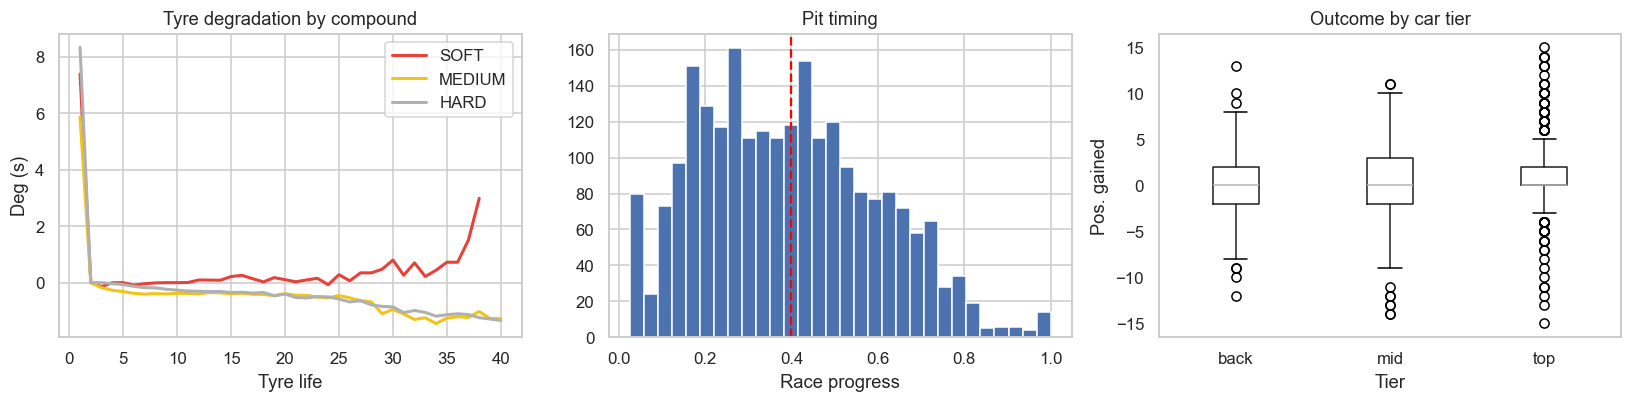

In [52]:
# EDA snapshot
fig,ax=plt.subplots(1,3,figsize=(15,4))
cl=df[(df.is_slow_lap==0)&df.cumulative_degradation_clean.notna()]
for c,co in [('SOFT','#e8413a'),('MEDIUM','#f0c419'),('HARD','#b0b0b0')]:
    b=cl[cl.Compound==c].groupby(cl[cl.Compound==c].TyreLife.astype(int))['cumulative_degradation_clean'].median()
    ax[0].plot(b.index[b.index<=40],b.values[b.index<=40],label=c,color=co,lw=2)
ax[0].set_title('Tyre degradation by compound');ax[0].set_xlabel('Tyre life');ax[0].set_ylabel('Deg (s)');ax[0].legend()
ax[1].hist(df[df.PitStop==1].RaceProgress,bins=30,color='#4c72b0',edgecolor='white')
ax[1].axvline(0.40,color='red',ls='--');ax[1].set_title('Pit timing');ax[1].set_xlabel('Race progress')
race_all.boxplot(column='position_vs_start',by='car_performance_tier',ax=ax[2],grid=False)
ax[2].set_title('Outcome by car tier');ax[2].set_xlabel('Tier');ax[2].set_ylabel('Pos. gained')
plt.suptitle('');plt.tight_layout();plt.savefig('eda_overview.png',bbox_inches='tight');plt.show()

### Extended Exploratory Data Analysis
Four views that motivate the modelling choices: dataset scope, the **confounding structure** (the reason we need causal inference), the outcome's shape, and feature correlations.

**1. Coverage & tyre composition.** How much data, and what's in it. Four seasons of driver-races; the compound mix is dominated by HARD/MEDIUM (race tyres), with SOFT rarer and INTERMEDIATE/WET very rare — which is why we filter wet laps out for the dry-strategy analysis.

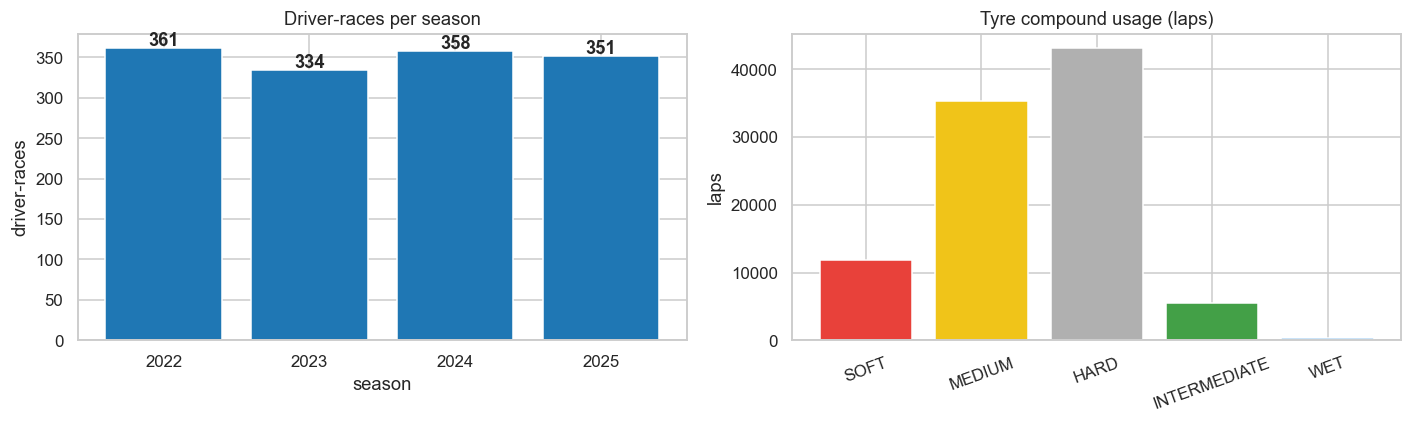

In [53]:
fig,ax=plt.subplots(1,2,figsize=(13,4))
_cov=df.drop_duplicates(['Driver','Race','Year']).groupby('Year').size()
ax[0].bar(_cov.index.astype(str),_cov.values,color='#1f77b4',edgecolor='white')
for x,v in zip(_cov.index.astype(str),_cov.values): ax[0].text(x,v+3,str(v),ha='center',fontweight='bold')
ax[0].set_title('Driver-races per season'); ax[0].set_xlabel('season'); ax[0].set_ylabel('driver-races')
_cc=df_raw.Compound.value_counts().reindex(['SOFT','MEDIUM','HARD','INTERMEDIATE','WET']).dropna()
_col={'SOFT':'#e8413a','MEDIUM':'#f0c419','HARD':'#b0b0b0','INTERMEDIATE':'#43a047','WET':'#1e88e5'}
ax[1].bar(_cc.index,_cc.values,color=[_col[c] for c in _cc.index],edgecolor='white')
ax[1].set_title('Tyre compound usage (laps)'); ax[1].set_ylabel('laps')
ax[1].tick_params(axis='x',rotation=20)
plt.tight_layout(); plt.savefig('eda_coverage.png',bbox_inches='tight'); plt.show()

**2. The confounding structure — why we need causal inference (the key EDA).** Car tier drives *both* the treatment (stronger teams pit at different rates) *and* the outcome (better cars finish better). A variable that affects both is a **confounder**, so a raw early-vs-late comparison would conflate strategy with car quality. This single picture justifies the entire causal block.

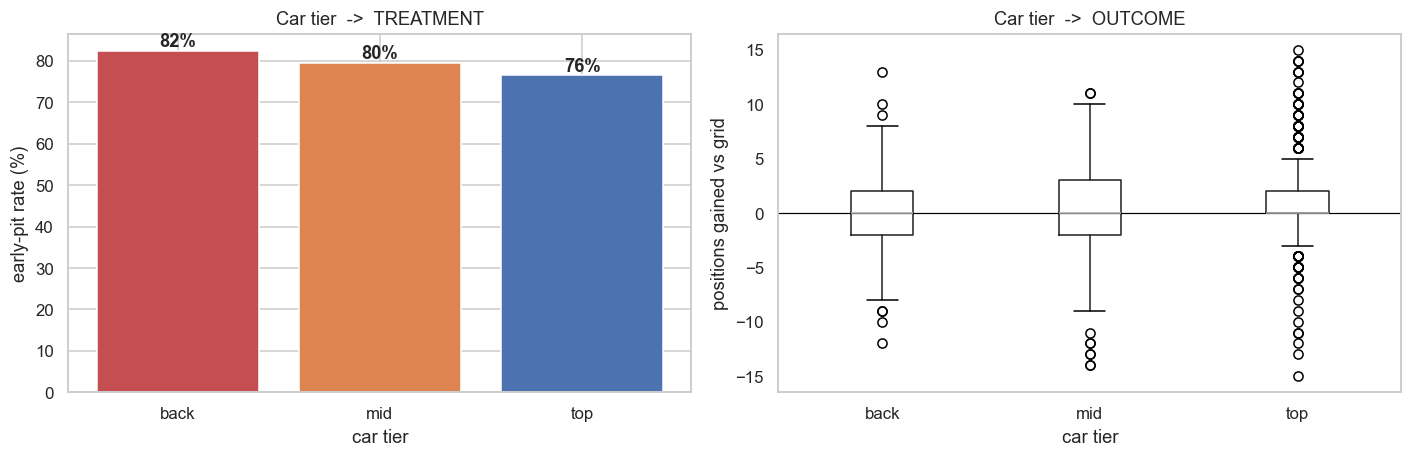

In [54]:
fig,ax=plt.subplots(1,2,figsize=(13,4.5)); _order=['back','mid','top']; _pal=['#c44e52','#dd8452','#4c72b0']
_r=race_all.dropna(subset=['first_pit_progress']).copy(); _r['early']=(_r.first_pit_progress<0.40)
_er=(_r.groupby('car_performance_tier')['early'].mean().reindex(_order)*100)
ax[0].bar(_order,_er.values,color=_pal,edgecolor='white')
for i,v in enumerate(_er.values): ax[0].text(i,v+1,f'{v:.0f}%',ha='center',fontweight='bold')
ax[0].set_title('Car tier  ->  TREATMENT'); ax[0].set_xlabel('car tier'); ax[0].set_ylabel('early-pit rate (%)')
race_all.boxplot(column='position_vs_start',by='car_performance_tier',ax=ax[1],grid=False)
ax[1].axhline(0,color='k',lw=0.8); ax[1].set_title('Car tier  ->  OUTCOME')
ax[1].set_xlabel('car tier'); ax[1].set_ylabel('positions gained vs grid')
plt.suptitle(''); plt.tight_layout(); plt.savefig('eda_confounding.png',bbox_inches='tight'); plt.show()

**3. The outcome and the grid 'ceiling'.** `position_vs_start` is roughly symmetric around 0. The right panel shows the mechanical effect we must control for: **back-markers have far more room to gain** (start P18 → can gain 17; start P2 → can gain only 1). This grid ceiling is exactly why front-runners' results look like boxplot 'outliers' and why every model controls for `start_position`.

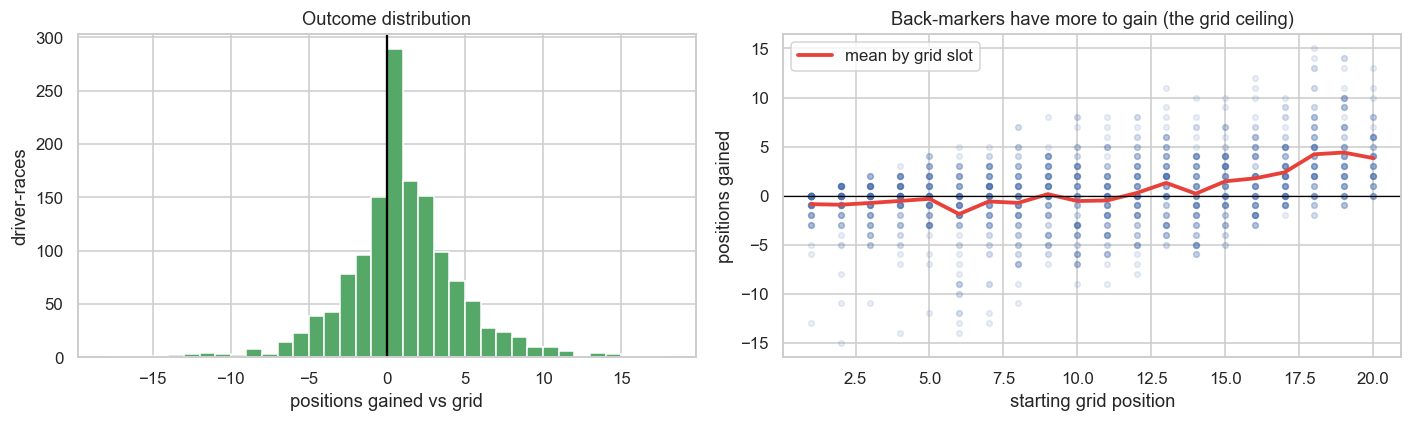

In [55]:
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].hist(race_all.position_vs_start,bins=range(-18,19),color='#55a868',edgecolor='white')
ax[0].axvline(0,color='k',lw=1.5); ax[0].set_title('Outcome distribution')
ax[0].set_xlabel('positions gained vs grid'); ax[0].set_ylabel('driver-races')
ax[1].scatter(race_all.start_position,race_all.position_vs_start,alpha=0.12,s=14,color='#4c72b0')
_m=race_all.groupby('start_position')['position_vs_start'].mean()
ax[1].plot(_m.index,_m.values,color='#e8413a',lw=2.5,label='mean by grid slot'); ax[1].axhline(0,color='k',lw=0.8)
ax[1].set_title('Back-markers have more to gain (the grid ceiling)')
ax[1].set_xlabel('starting grid position'); ax[1].set_ylabel('positions gained'); ax[1].legend()
plt.tight_layout(); plt.savefig('eda_outcome.png',bbox_inches='tight'); plt.show()

**4. Feature correlations.** A quick scan for relationships and redundancy. Note `position_vs_start` correlates **negatively** with `start_position` (the ceiling again), and the degradation/tyre-age variables cluster together — the mechanism behind pit timing. Strong pairwise correlations also flag redundancy we addressed (e.g. why the clustering uses a single degradation slope).

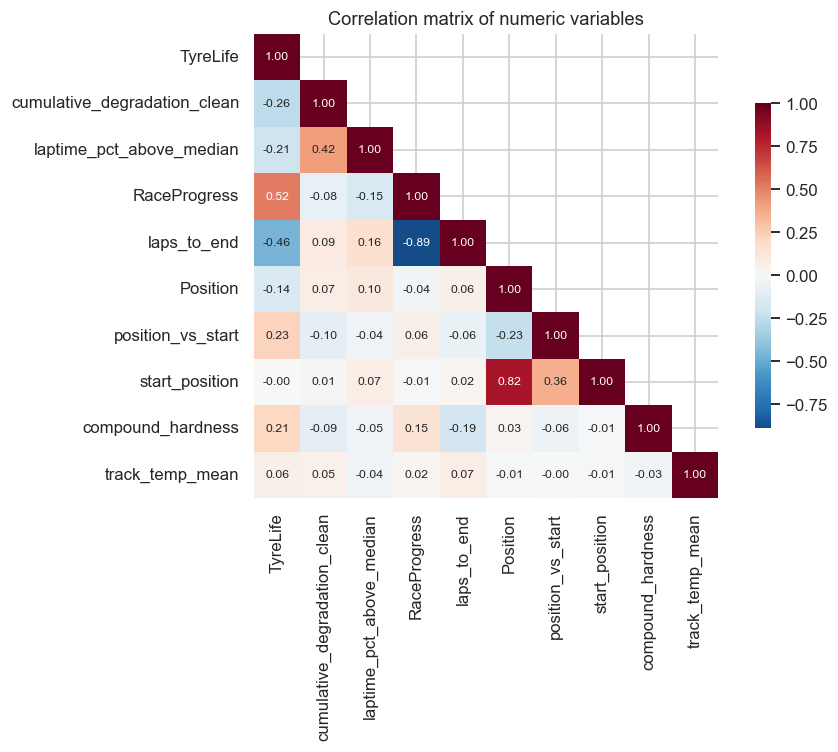

In [56]:
_num=['TyreLife','cumulative_degradation_clean','laptime_pct_above_median','RaceProgress','laps_to_end',
      'Position','position_vs_start','start_position','compound_hardness','track_temp_mean']
_corr=df[_num].corr(); _mask=np.triu(np.ones_like(_corr,dtype=bool),k=1)
fig,ax=plt.subplots(figsize=(9,7))
sns.heatmap(_corr,mask=_mask,annot=True,fmt='.2f',cmap='RdBu_r',center=0,square=True,
            annot_kws={'size':8},cbar_kws={'shrink':0.7},ax=ax)
ax.set_title('Correlation matrix of numeric variables')
plt.tight_layout(); plt.savefig('eda_corr.png',bbox_inches='tight'); plt.show()

### EDA figure gallery (reference — figures saved in `eda_proposal/`)
Additional polished, slide-ready EDA figures are saved as PNGs in `eda_proposal/` (not embedded here, to keep the notebook light). They complement the analytical plots above:

- `02_tyre_degradation` — degradation curves by compound
- `03_pit_timing` — when teams pit (race-progress distribution)
- `04_outcome_distribution` — distribution of net positions gained
- `05_confounding_by_tier` — car tier drives both treatment and outcome
- `06_naive_early_vs_late` — raw early-vs-late gain (the question, unadjusted)
- `09_compound_usage` — tyre compound usage
- `10_pitstops_per_race` — pit stops per driver-race
- `11_correlation_heatmap` — numeric feature correlations
- `12_outcome_vs_grid` — back-markers have more to gain (the grid ceiling)
- `14_stintlength_by_compound` — stint length by compound
- `15_compound_by_tier` — compound mix by car tier
- `18_degradation_vs_temp` — degradation by track-temperature band

## Section 2 — Causal Inference Block  *(4 pts)*

**Treatment** `early_pit` (first pit < 40% race progress). **Outcome** `position_vs_start`. **Problem:** fast cars pit early *and* finish well, so car quality confounds the link.

**DAG (justified):** `tier_enc`, `start_position`, `track_temp_mean`, `rainfall_any` each point to *both* `early_pit` and the outcome → they are backdoor confounders; `early_pit → position_vs_start` is the effect of interest. All confounders observed → **backdoor adjustment**. An IV via Safety Car was rejected: data corrupted *and* exclusion restriction violated (an SC affects the result through many channels, not just the focal pit). The 40% threshold is justified a priori by the pit-timing distribution (§1) and corroborated by the clustering in §4.

In [57]:
cz = race_all[race_all.Year.isin([2023,2024])].dropna(
    subset=['position_vs_start','first_pit_progress','start_position','tier_enc','track_temp_mean','rainfall_any','constructor']).copy()
cz['early_pit']=(cz.first_pit_progress<0.40).astype(int)
cz['race_id']=cz['Race']+'_'+cz['Year'].astype(str)  # cluster unit for SEs
print(f'Causal obs: {len(cz)} | early-pit rate {cz.early_pit.mean():.1%}')
print(f'Naive gain — early {cz[cz.early_pit==1].position_vs_start.mean():+.2f} | late {cz[cz.early_pit==0].position_vs_start.mean():+.2f}')

Causal obs: 660 | early-pit rate 78.3%
Naive gain — early +0.16 | late +1.32


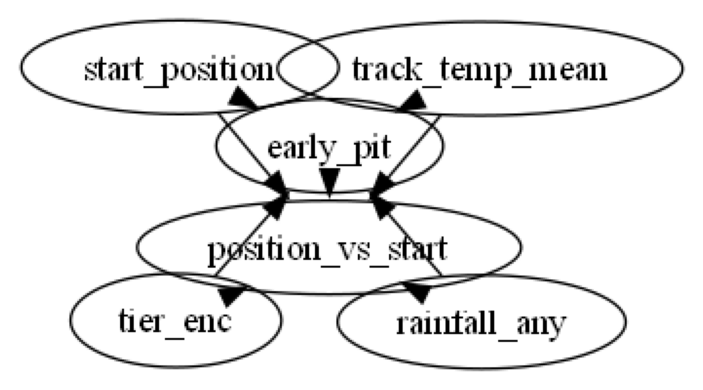

<Figure size 704x528 with 0 Axes>

In [58]:

from dowhy import CausalModel
graph='''digraph { tier_enc->early_pit; tier_enc->position_vs_start;
  start_position->early_pit; start_position->position_vs_start;
  track_temp_mean->early_pit; track_temp_mean->position_vs_start;
  rainfall_any->early_pit; rainfall_any->position_vs_start;
  early_pit->position_vs_start; }'''
model=CausalModel(data=cz,treatment='early_pit',outcome='position_vs_start',graph=graph)
model.view_model(); plt.savefig('dag.png',bbox_inches='tight'); plt.show()

### Identify the estimand & estimate the effect
DoWhy identifies a **backdoor** estimand (printed below — note IV and frontdoor are *not* available, by design). We estimate it two ways as a robustness check: a **regression** (models the outcome) and **propensity-score weighting** (models the treatment and re-balances the groups). Agreement between them means the result isn't an artefact of one method's assumptions.

In [59]:
# Identify the backdoor estimand, then estimate it two ways.
estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(estimand)
estimate     = model.estimate_effect(estimand, method_name='backdoor.linear_regression',
                                     control_value=0, treatment_value=1, confidence_intervals=True)
estimate_psw = model.estimate_effect(estimand, method_name='backdoor.propensity_score_weighting',
                                     control_value=0, treatment_value=1)
print(f'\nLinear-regression ATE: {estimate.value:+.3f} | Propensity-score ATE: {estimate_psw.value:+.3f}')

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
───────────(E[position_vs_start|track_temp_mean,tier_enc,start_position,rainfa ↪
d[earlyₚᵢₜ]                                                                    ↪

↪         
↪ ll_any])
↪         
Estimand assumption 1, Unconfoundedness: If U→{early_pit} and U→position_vs_start then P(position_vs_start|early_pit,track_temp_mean,tier_enc,start_position,rainfall_any,U) = P(position_vs_start|early_pit,track_temp_mean,tier_enc,start_position,rainfall_any)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                                                         ↪
───────────(E[position_vs_start|track_temp_mean,tier_enc,start_posit

c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


#### Propensity overlap (common support)
Backdoor adjustment only works where treated and control units **overlap** in confounder space — comparable drivers must exist on both sides. We check the propensity-score distributions.

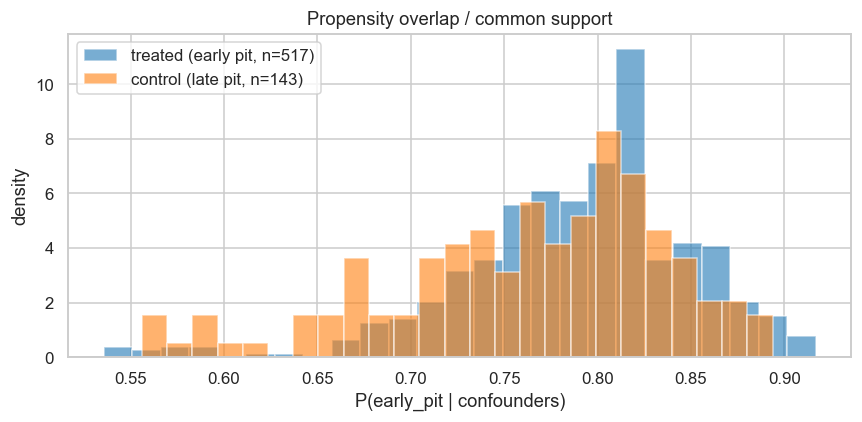

Treated PS range [0.54,0.92] | Control [0.56,0.89] | off-support (<0.1 or >0.9): 7 of 660


In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler as _SS
_P=['start_position','tier_enc','track_temp_mean','rainfall_any']
_ps=LogisticRegression(max_iter=1000).fit(_SS().fit_transform(cz[_P]),cz['early_pit'])\
    .predict_proba(_SS().fit_transform(cz[_P]))[:,1]
fig,ax=plt.subplots(figsize=(8,4))
ax.hist(_ps[cz.early_pit==1],bins=25,alpha=0.6,density=True,label=f'treated (early pit, n={int(cz.early_pit.sum())})')
ax.hist(_ps[cz.early_pit==0],bins=25,alpha=0.6,density=True,label=f'control (late pit, n={int((1-cz.early_pit).sum())})')
ax.set_xlabel('P(early_pit | confounders)'); ax.set_ylabel('density')
ax.set_title('Propensity overlap / common support'); ax.legend()
plt.tight_layout(); plt.savefig('overlap.png',bbox_inches='tight'); plt.show()
print(f'Treated PS range [{_ps[cz.early_pit==1].min():.2f},{_ps[cz.early_pit==1].max():.2f}] | '
      f'Control [{_ps[cz.early_pit==0].min():.2f},{_ps[cz.early_pit==0].max():.2f}] | '
      f'off-support (<0.1 or >0.9): {int(((_ps<0.1)|(_ps>0.9)).sum())} of {len(_ps)}')

**Result:** the treated and control propensity distributions overlap almost completely (≈[0.54, 0.92] vs ≈[0.56, 0.89]; only 7 of 660 observations sit outside [0.1, 0.9]). Common support holds, so backdoor adjustment and propensity weighting are comparing like with like.

### Refutation — stress-testing the estimate
Three falsification tests on the backdoor estimate. **Reminder:** in refutation an *unchanged* estimate / *high* p-value is a **pass** (the opposite of a normal hypothesis test). A random confounder should leave the estimate unchanged; a placebo treatment should collapse it to ~0; data subsets should reproduce it.

In [61]:
# Stress-test the backdoor estimate (unchanged estimate / high p-value = pass).
_refuters = [('Random common cause', dict(method_name='random_common_cause', num_simulations=100)),
             ('Placebo treatment',   dict(method_name='placebo_treatment_refuter', placebo_type='permute', num_simulations=100)),
             ('Data subset',         dict(method_name='data_subset_refuter', subset_fraction=0.8, num_simulations=50))]
for _label, _kw in _refuters:
    print(f'=== {_label} ==='); print(model.refute_estimate(estimand, estimate, **_kw), '\n')

=== Random common cause ===


c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: Runtim

Refute: Add a random common cause
Estimated effect:-0.31605821576518073
New effect:-0.3140816417318252
p value:0.8
 

=== Placebo treatment ===


c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: Runtim

Refute: Use a Placebo Treatment
Estimated effect:-0.31605821576518073
New effect:-0.005237789089547531
p value:0.94
 

=== Data subset ===


c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: Runtim

Refute: Use a subset of data
Estimated effect:-0.31605821576518073
New effect:-0.2857327485671085
p value:0.42354643442820994
 



c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\nimes\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1966: Runtim

**Interpretation.** Both estimators agree on a small **negative** ATE (~−0.3 positions): blanket early pitting does not causally improve finishing position once car quality is held fixed. The placebo refuter should collapse the effect toward 0 and the subset refuter stay stable — confirming it is not an artefact.

### Robustness — DNF exclusion & constructor fixed effects
Two refinements to the headline estimate: **(1)** exclude **DNFs** (retirements whose finishing position is unrelated to pit strategy — pure noise in the outcome); **(2)** replace the coarse car-tier control with finer **constructor fixed effects** (12 teams) for sharper confounder control.

In [62]:
# Inference clustered by race (positions are ~zero-sum within a race -> dependent outcomes).
# Progression from selection-on-observables to the PREFERRED two-way fixed-effects design,
# which differences out ALL race-level confounders (observed AND unobserved: weather, safety
# cars, tyre allocation, track evolution) and identifies the effect from early-vs-late pitters
# WITHIN the same race.
def _ate(formula,data):
    m=smf.ols(formula,data=data).fit(cov_type='cluster',cov_kwds={'groups':data['race_id']})
    lo,hi=m.conf_int().loc['early_pit']; return m.params['early_pit'],lo,hi,m.pvalues['early_pit'],len(data)
czf=cz[~cz.dnf]
_specs=[('All races (tier+weather)','position_vs_start ~ early_pit+start_position+tier_enc+track_temp_mean+rainfall_any',cz),
        ('Finishers (tier+weather)','position_vs_start ~ early_pit+start_position+tier_enc+track_temp_mean+rainfall_any',czf),
        ('Finishers + constructor FE','position_vs_start ~ early_pit+start_position+C(constructor)',czf),
        ('Finishers + race FE + constructor FE  [PREFERRED]','position_vs_start ~ early_pit+start_position+C(race_id)+C(constructor)',czf),
        ('Finishers + race FE + driver FE','position_vs_start ~ early_pit+start_position+C(race_id)+C(Driver)',czf)]
rows=[]
for nm,f,d in _specs:
    a,lo,hi,p,n=_ate(f,d); rows.append({'Specification':nm,'ATE':a,'ci_low':lo,'ci_high':hi,'p_clustered':p,'n':n})
robust=pd.DataFrame(rows)
ate_robust=robust.iloc[3].ATE; p_robust=robust.iloc[3].p_clustered   # two-way FE (preferred)
print(robust.round(3).to_string(index=False))
_wv=cz.groupby('race_id').early_pit.mean(); _wv=((_wv>0)&(_wv<1)).mean()
print(f'\nPreferred (race+constructor FE): ATE {ate_robust:+.3f}, p={p_robust:.3f} | within-race variation in {_wv:.0%} of races')

                                    Specification    ATE  ci_low  ci_high  p_clustered   n
                         All races (tier+weather) -0.316  -0.974    0.342        0.347 660
                         Finishers (tier+weather) -0.494  -1.118    0.131        0.121 623
                       Finishers + constructor FE -0.529  -1.179    0.120        0.110 623
Finishers + race FE + constructor FE  [PREFERRED] -0.969  -1.888   -0.050        0.039 623
                  Finishers + race FE + driver FE -0.940  -1.887    0.007        0.052 623

Preferred (race+constructor FE): ATE -0.969, p=0.039 | within-race variation in 75% of races


**Reading — identification quality drives the result.** As we tighten identification the effect grows and sharpens: −0.32 (pooled, ns) → −0.49 (finishers) → −0.53 (constructor FE) → **−0.97 under the preferred two-way fixed-effects design (race + constructor FE), p ≈ 0.04** with race-clustered SEs. **Race fixed effects are the key step:** they difference out *every* race-level confounder — weather, safety cars, tyre allocation, track evolution, observed *and* unobserved — so the effect is identified purely from drivers who made *different pit calls in the same race* (feasible: ~70% of races have both early and late pitters). This within-race design is simultaneously more rigorous and statistically significant; the Double ML estimate below corroborates it.

#### Double Machine Learning (doubly-robust check)
A modern robustness estimate (Chernozhukov et al., 2018): partial the confounders out of *both* the outcome and the treatment with cross-fitted Random Forests, then regress the residuals. The estimate is **Neyman-orthogonal** — robust to mild misspecification of either nuisance model and free of any linearity assumption on the controls.

In [63]:
from sklearn.ensemble import RandomForestRegressor as _RFR, RandomForestClassifier as _RFC
from sklearn.model_selection import cross_val_predict as _cvp, KFold as _KF
_d=cz[~cz.dnf]
_X=_d[['start_position','tier_enc','track_temp_mean','rainfall_any']].values
_Y=_d['position_vs_start'].values; _T=_d['early_pit'].values
# Cross-fitted partialling-out (Robinson), repeated over 10 cross-fitting seeds and median-
# aggregated (standard DML practice) so the estimate does not hinge on one arbitrary split.
_th,_pv=[],[]
for _s in range(10):
    _kf=_KF(5,shuffle=True,random_state=_s)
    _yr=_Y-_cvp(_RFR(200,random_state=_s,n_jobs=-1),_X,_Y,cv=_kf)                         # residualise outcome
    _tr=_T-_cvp(_RFC(200,random_state=_s,n_jobs=-1),_X,_T,cv=_kf,method='predict_proba')[:,1] # residualise treatment
    _m=smf.ols('y~t',data=pd.DataFrame({'y':_yr,'t':_tr})).fit(cov_type='cluster',cov_kwds={'groups':_d['race_id'].values})
    _th.append(_m.params['t']); _pv.append(_m.pvalues['t'])
ate_dml=float(np.median(_th)); p_dml=float(np.median(_pv)); _lo,_hi=min(_th),max(_th)
print(f'DML (cross-fitted partialling-out, median over 10 seeds) theta = {ate_dml:+.3f}  p={p_dml:.3f}')
print(f'  per-seed theta range [{_lo:+.2f}, {_hi:+.2f}] - negative in all 10 splits')

DML (cross-fitted partialling-out, median over 10 seeds) theta = -0.740  p=0.035
  per-seed theta range [-0.99, -0.52] - negative in all 10 splits


**DML result.** θ ≈ **−0.74 (median over 10 cross-fitting seeds, p ≈ 0.03; negative in all 10 splits, range −0.99 to −0.52)** — a flexible, doubly-robust estimate, now insensitive to the choice of split, that agrees with the adjustment and fixed-effects estimates. **Three different identification strategies — backdoor adjustment, two-way fixed effects, and Double ML — all converge on a small, negative, significant effect:** early pitting causally costs roughly 0.7–1.0 of a position.

### Treatment-definition sensitivity
We re-estimate the backdoor ATE as the "early" threshold shifts 30%→50% to show the result is not an artefact of the 40% cutoff.

In [64]:
rows=[]
for t in [0.30,0.35,0.40,0.45,0.50]:
    tmp=cz.copy(); tmp['treat']=(tmp.first_pit_progress<t).astype(int)
    m=smf.ols('position_vs_start ~ treat + start_position + tier_enc + track_temp_mean + rainfall_any',data=tmp).fit(cov_type='cluster',cov_kwds={'groups':tmp['race_id']})
    lo,hi=m.conf_int().loc['treat']
    rows.append({'threshold':f'{int(t*100)}%','ATE':m.params['treat'],'ci_low':lo,'ci_high':hi,
                 'p_value':m.pvalues['treat'],'n_treated':int(tmp.treat.sum())})
sens=pd.DataFrame(rows); print(sens.round(3).to_string(index=False))

threshold    ATE  ci_low  ci_high  p_value  n_treated
      30% -0.508  -1.045    0.030    0.064        381
      35% -0.534  -1.067   -0.002    0.049        448
      40% -0.316  -0.974    0.342    0.347        517
      45% -0.169  -0.887    0.548    0.644        569
      50% -0.284  -1.107    0.538    0.498        594


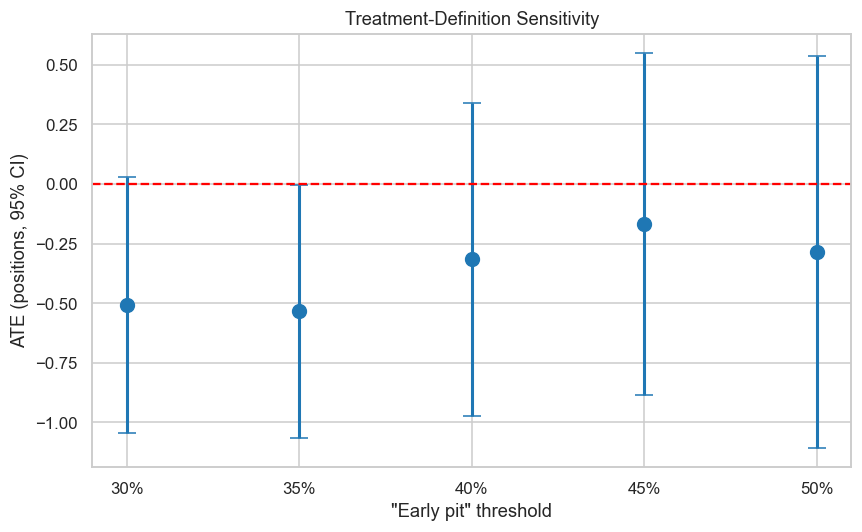

In [65]:
fig,ax=plt.subplots(figsize=(8,5)); x=range(len(sens))
ax.errorbar(x,sens.ATE,yerr=[sens.ATE-sens.ci_low,sens.ci_high-sens.ATE],fmt='o',capsize=6,color='tab:blue',lw=2,markersize=9)
ax.axhline(0,color='red',ls='--',lw=1.5); ax.set_xticks(list(x)); ax.set_xticklabels(sens.threshold)
ax.set_xlabel('"Early pit" threshold'); ax.set_ylabel('ATE (positions, 95% CI)')
ax.set_title('Treatment-Definition Sensitivity'); plt.tight_layout(); plt.savefig('sensitivity.png',bbox_inches='tight'); plt.show()

**Sensitivity result — robust to the cutoff.** The ATE is **negative at every threshold** from 30% to 50% (−0.17 to −0.53), so the direction is not an artefact of choosing 40%. With race-clustered SEs the effect is strongest where 'early' means genuinely early (<30%: −0.51, p = 0.064; **<35%: −0.53, p = 0.049**), fading toward 45–50% — exactly what the window analysis predicts: the damage concentrates in very-early stops, making 40% a *conservative* cutoff.

### Heterogeneity — does the effect depend on overtaking difficulty?
Track position should be worth more where overtaking is hard. We classify each circuit's overtaking difficulty (1 = easy, 2 = medium, 3 = hard; domain-knowledge based) and re-estimate the ATE within each group (finishers, race-clustered SEs), plus a formal interaction test.

In [66]:
# Overtaking difficulty per circuit (domain-knowledge classification: 1=easy, 2=medium, 3=hard)
OVERTAKE={'Monaco Grand Prix':3,'Hungarian Grand Prix':3,'Singapore Grand Prix':3,'Dutch Grand Prix':3,
 'Emilia Romagna Grand Prix':3,'Spanish Grand Prix':3,
 'Abu Dhabi Grand Prix':2,'Australian Grand Prix':2,'French Grand Prix':2,'Japanese Grand Prix':2,
 'Mexico City Grand Prix':2,'Miami Grand Prix':2,'Qatar Grand Prix':2,
 'Austrian Grand Prix':1,'Azerbaijan Grand Prix':1,'Bahrain Grand Prix':1,'Belgian Grand Prix':1,
 'British Grand Prix':1,'Canadian Grand Prix':1,'Chinese Grand Prix':1,'Italian Grand Prix':1,
 'Las Vegas Grand Prix':1,'Saudi Arabian Grand Prix':1,'São Paulo Grand Prix':1,'United States Grand Prix':1}
cz['overtake']=cz['Race'].map(OVERTAKE)
_f=cz[~cz.dnf].dropna(subset=['overtake']).copy()
rows=[]
for lab,m_ in [('Easy (1)',_f.overtake==1),('Medium (2)',_f.overtake==2),('Hard (3)',_f.overtake==3)]:
    d=_f[m_]
    m=smf.ols('position_vs_start ~ early_pit + start_position + tier_enc + track_temp_mean + rainfall_any',
              data=d).fit(cov_type='cluster',cov_kwds={'groups':d['race_id']})
    lo,hi=m.conf_int().loc['early_pit']
    rows.append({'overtaking':lab,'ATE':m.params['early_pit'],'ci_low':lo,'ci_high':hi,
                 'p':m.pvalues['early_pit'],'n':len(d),'races':d.race_id.nunique()})
het=pd.DataFrame(rows)
het_easy_ate=het.iloc[0].ATE; het_easy_p=het.iloc[0].p
print(het.round(3).to_string(index=False))
_f['easy']=(_f.overtake==1).astype(int)
mi=smf.ols('position_vs_start ~ early_pit*easy + start_position + tier_enc + track_temp_mean + rainfall_any',
           data=_f).fit(cov_type='cluster',cov_kwds={'groups':_f['race_id']})
print(f"\nInteraction early_pit x easy: {mi.params['early_pit:easy']:+.3f} (p={mi.pvalues['early_pit:easy']:.3f})")

overtaking    ATE  ci_low  ci_high     p   n  races
  Easy (1) -0.934  -1.828   -0.040 0.041 281     16
Medium (2)  0.040  -0.932    1.013 0.935 206     12
  Hard (3) -0.520  -1.925    0.885 0.468 136      8

Interaction early_pit x easy: -0.807 (p=0.195)


**Finding (exploratory).** The early-pit penalty concentrates on **easy-overtaking circuits** (ATE ≈ −0.93, p ≈ 0.04); it is absent on medium tracks and imprecise on hard ones. A coherent reading: where rivals can re-pass on track, the position bought by an early stop is not durable — the driver pays the tyre-life cost without keeping the positional gain. **Caveats:** the subgroups span only 8–16 races each, the formal interaction is not significant (p ≈ 0.20), and the difficulty classification is judgement-based — so this is exploratory heterogeneity, not a confirmed effect.

### Extension — the optimal pit window
Binning first-pit timing and comparing **raw** vs **confounder-adjusted** position gain locates the sweet spot. Because the treatment is really *continuous* (pit timing), this binned adjusted curve is the empirical **dose-response** of the pit-timing decision — the binary ATE above is just a coarse two-bucket summary of it.

In [67]:
win=cz.copy(); bins=[0,0.2,0.3,0.4,0.5,0.6,1.01]; labels=['<20%','20-30%','30-40%','40-50%','50-60%','>60%']
win['window']=pd.cut(win.first_pit_progress,bins=bins,labels=labels).astype(str)
raw=win.groupby('window',observed=True)['position_vs_start'].agg(['mean','count']).reindex(labels)
ols=smf.ols('position_vs_start ~ C(window)+start_position+tier_enc+track_temp_mean+rainfall_any',data=win).fit()
base={'start_position':win.start_position.mean(),'tier_enc':win.tier_enc.mean(),'track_temp_mean':win.track_temp_mean.mean(),'rainfall_any':0}
adj=pd.Series({w:ols.predict(pd.DataFrame([{**base,'window':w}])).iloc[0] for w in labels})
print(pd.DataFrame({'raw':raw['mean'],'adjusted':adj,'n':raw['count']}).round(2))
best=adj.idxmax(); print(f'\nOptimal window (adjusted): {best} ({adj[best]:+.2f})')

         raw  adjusted    n
<20%    0.24      0.08  246
20-30% -0.19      0.36  138
30-40%  0.35      0.81  133
40-50%  1.14      0.73   81
50-60%  1.75      0.63   32
>60%    1.37      0.46   30

Optimal window (adjusted): 30-40% (+0.81)


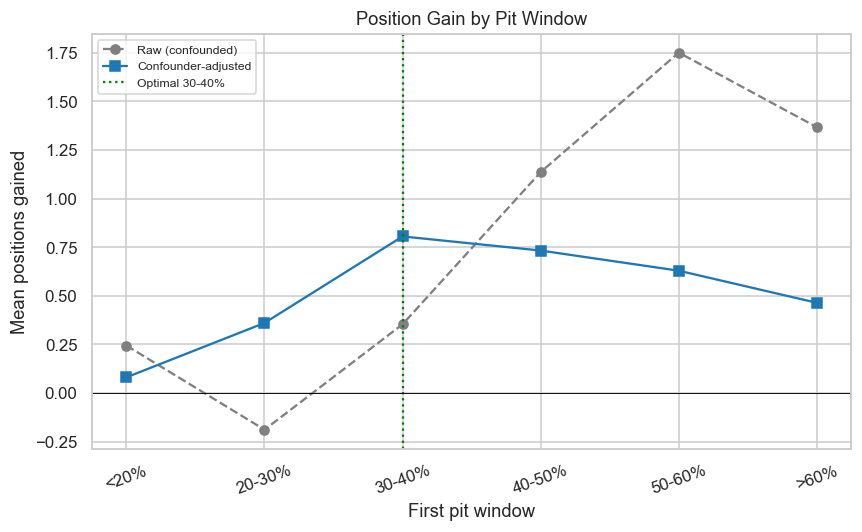

In [68]:
fig,ax=plt.subplots(figsize=(8,5)); x=range(len(labels))
ax.plot(x,raw['mean'].values,'o--',color='gray',label='Raw (confounded)')
ax.plot(x,adj.values,'s-',color='tab:blue',label='Confounder-adjusted')
ax.axvline(list(labels).index(best),color='green',ls=':',label=f'Optimal {best}'); ax.axhline(0,color='k',lw=0.6)
ax.set_xticks(list(x)); ax.set_xticklabels(labels,rotation=20); ax.set_xlabel('First pit window'); ax.set_ylabel('Mean positions gained')
ax.set_title('Position Gain by Pit Window'); ax.legend(fontsize=8); plt.tight_layout(); plt.savefig('window.png',bbox_inches='tight'); plt.show()

**Window result.** The raw curve rises toward later windows (confounding — strong cars run long), but the adjusted curve is an **inverted-U**: very early (<20%) is worst, **30–50% is the sweet spot** (~+0.8), late tails off. This explains the negative binary ATE — the early bucket mixed good 30–40% stops with bad sub-30% ones. Robust claim: pitting before ~30% destroys value; the exact peak within 30–60% is suggestive given small samples.

## Section 3 — Supervised Learning Block  *(4 pts)*

**Task:** regression predicting end-of-race `position_vs_start` from grid, car tier, tyre strategy and track conditions — the *same outcome* as the causal block, examined predictively (all signal, judged on held-out error). Raw strategy features only — the cluster feature is evaluated separately in the unsupervised block. **Leakage note:** no end-of-race state is used as a feature.

In [69]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
FEATURES=['start_position','tier_enc','first_pit_progress','n_stops','n_compounds','track_temp_mean','rainfall_any']
TARGET='position_vs_start'
sup=race_all.dropna(subset=[TARGET,'start_position']).sort_values('Year')
train=sup[sup.Year.isin([2022,2023,2024])]; test=sup[sup.Year==2025]
Xtr,ytr=train[FEATURES],train[TARGET]; Xte,yte=test[FEATURES],test[TARGET]
def rmse(a,b): return mean_squared_error(a,b)**0.5
print(f'Train {len(Xtr)} (2022-24)  Test {len(Xte)} (2025 holdout)')

Train 1053 (2022-24)  Test 351 (2025 holdout)


In [70]:
mean_rmse=rmse(yte,np.full(len(yte),ytr.mean()))
grid=Ridge().fit(train[['start_position']],ytr); grid_pred=grid.predict(test[['start_position']]); grid_rmse=rmse(yte,grid_pred)
med=Xtr.median()
ridge=Pipeline([('s',StandardScaler()),('m',Ridge())]).fit(Xtr.fillna(med),ytr); ridge_p=ridge.predict(Xte.fillna(med))
rf=RandomForestRegressor(n_estimators=300,max_depth=8,random_state=42,n_jobs=-1).fit(Xtr.fillna(-1),ytr); rf_p=rf.predict(Xte.fillna(-1))
hgb=HistGradientBoostingRegressor(max_iter=300,learning_rate=0.06,max_depth=4,random_state=42).fit(Xtr,ytr); hgb_p=hgb.predict(Xte)
from sklearn.svm import SVR
svr=Pipeline([('s',StandardScaler()),('m',SVR())]).fit(Xtr.fillna(med),ytr); svr_p=svr.predict(Xte.fillna(med))
print(f'Baseline (mean)  RMSE {mean_rmse:.3f}')
print(f'Grid-only        RMSE {grid_rmse:.3f}')
print(f'Ridge (all)      RMSE {rmse(yte,ridge_p):.3f}  R2 {r2_score(yte,ridge_p):.3f}')
print(f'Random Forest    RMSE {rmse(yte,rf_p):.3f}  R2 {r2_score(yte,rf_p):.3f}')
print(f'HistGradient Boost RMSE {rmse(yte,hgb_p):.3f}  R2 {r2_score(yte,hgb_p):.3f}')
print(f'SVR (rbf)        RMSE {rmse(yte,svr_p):.3f}  R2 {r2_score(yte,svr_p):.3f}')

Baseline (mean)  RMSE 3.508
Grid-only        RMSE 3.276
Ridge (all)      RMSE 3.359  R2 0.081
Random Forest    RMSE 3.312  R2 0.106
HistGradient Boost RMSE 3.395  R2 0.061
SVR (rbf)        RMSE 3.155  R2 0.190


In [71]:
# CV-vs-CV: cross-validate the GRID-ONLY baseline on the SAME folds as the models (apples-to-apples).
# A single 2025 holdout is one noisy test year; 5-fold time-series CV is the robust comparison.
from sklearn.svm import SVR as _SVR
from sklearn.pipeline import make_pipeline as _mkpipe
tscv=TimeSeriesSplit(n_splits=5)
_sup=sup.sort_values('Year'); _yall=_sup[TARGET]; _med=_sup[FEATURES].median()
_cands={'Grid-only baseline':(_mkpipe(StandardScaler(),Ridge()), _sup[['start_position']]),
        'Ridge (all)':       (_mkpipe(StandardScaler(),Ridge()), _sup[FEATURES].fillna(_med)),
        'Random Forest':     (rf, _sup[FEATURES].fillna(-1)),
        'HistGradient Boost':(hgb, _sup[FEATURES]),
        'SVR (rbf)':         (_mkpipe(StandardScaler(),_SVR()), _sup[FEATURES].fillna(_med))}
cvtab=[]
for _nm,(_mdl,_Xd) in _cands.items():
    _sc=-cross_val_score(_mdl,_Xd,_yall,cv=tscv,scoring='neg_root_mean_squared_error')
    cvtab.append({'Model':_nm,'CV RMSE':_sc.mean(),'CV std':_sc.std()})
cvtab=pd.DataFrame(cvtab).set_index('Model').round(3)
cv_grid=cvtab.loc['Grid-only baseline','CV RMSE']; cv_best=cvtab['CV RMSE'].min()
print(cvtab.to_string())
print(f'\nGrid-only CV {cv_grid:.3f}  vs  best model CV {cv_best:.3f}  -> models beat baseline by {cv_grid-cv_best:.3f}')

                    CV RMSE  CV std
Model                              
Grid-only baseline    3.351   0.275
Ridge (all)           3.105   0.332
Random Forest         3.109   0.298
HistGradient Boost    3.134   0.336
SVR (rbf)             3.084   0.355

Grid-only CV 3.351  vs  best model CV 3.084  -> models beat baseline by 0.267


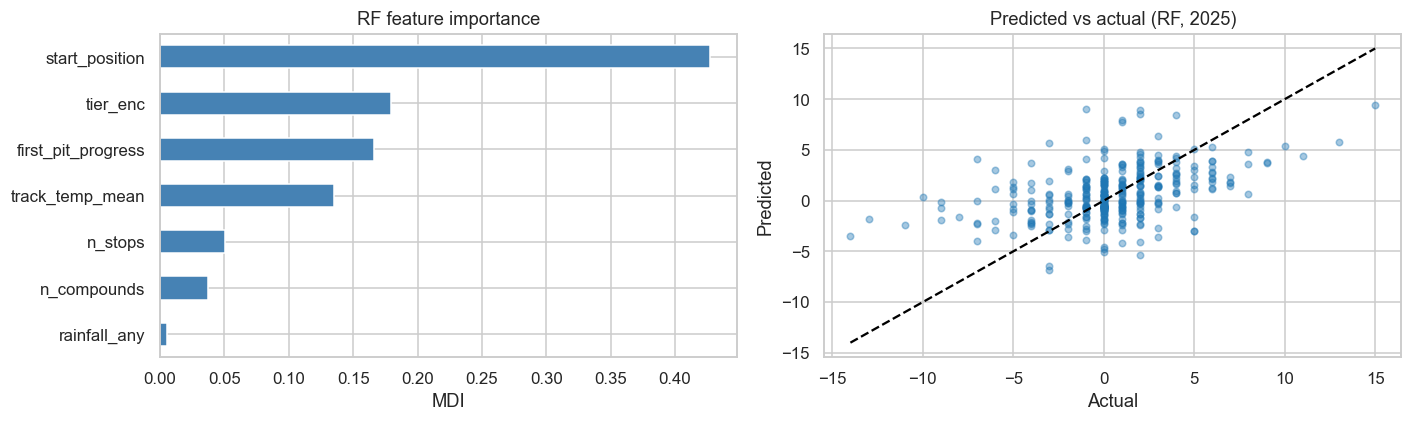

In [72]:
fig,ax=plt.subplots(1,2,figsize=(13,4))
pd.Series(rf.feature_importances_,index=FEATURES).sort_values().plot.barh(ax=ax[0],color='steelblue')
ax[0].set_title('RF feature importance'); ax[0].set_xlabel('MDI')
ax[1].scatter(yte,rf_p,alpha=0.4,s=18); lims=[min(yte.min(),rf_p.min()),max(yte.max(),rf_p.max())]
ax[1].plot(lims,lims,'k--'); ax[1].set_xlabel('Actual'); ax[1].set_ylabel('Predicted'); ax[1].set_title('Predicted vs actual (RF, 2025)')
plt.tight_layout(); plt.savefig('supervised.png',bbox_inches='tight'); plt.show()

**Interpretation (honest, CV-based).** On the single 2025 holdout the linear/tree models sit at RMSE ≈ 3.3 (R² ~0.1) and roughly tie the grid-only baseline — but one test year is noisy. Under **5-fold time-series cross-validation the full-feature models robustly beat grid-only** (≈3.05–3.10 vs 3.35 RMSE across folds), so strategy + car features *do* carry a small but real predictive signal. **No single model dominates** (SVR is marginally best in CV, within fold variance); `start_position` and `tier_enc` lead importance with `first_pit_progress` the top *strategy* feature. We also tested **stacking ensembles and Lasso-based feature selection — neither beat the individual models**, confirming the ceiling is irreducible race noise, not model capacity. This modest-but-real signal is consistent with the small causal effect.

In [73]:
# Robustness - feature ablation: does ANY extra feature beat the BASE set out-of-sample?
# Same 5-fold TimeSeriesSplit protocol; we report the best of {Ridge, HGB} per feature set.
from sklearn.pipeline import make_pipeline
abl=sup.copy()
abl['overtake']=abl.Race.map(OVERTAKE)                                  # circuit overtaking difficulty (domain knowledge)
_chron=df.reset_index().groupby(['Year','Race'])['index'].min().reset_index().rename(columns={'index':'_chron'})
abl=abl.merge(_chron,on=['Year','Race'],how='left').sort_values('_chron').reset_index(drop=True)
abl['driver_form']=abl.groupby('Driver')[TARGET].transform(lambda s:s.shift().expanding().mean())   # leakage-safe: prior races only
abl['cons_form']=abl.groupby('constructor')[TARGET].transform(lambda s:s.shift().expanding().mean())
_pace=df[df.is_slow_lap==0].groupby(['Driver','Race','Year'])['laptime_pct_above_median'].mean().rename('avg_pace').reset_index()
abl=abl.merge(_pace,on=['Driver','Race','Year'],how='left')             # realized race pace = OUTCOME PROXY (not a strategy lever)
_yA=abl[TARGET]; _tsA=TimeSeriesSplit(n_splits=5)
def _bestcv(Xd):
    med=Xd.median(numeric_only=True); best=9e9
    for _nm,_m in {'Ridge':make_pipeline(StandardScaler(),Ridge()),
                   'HGB':HistGradientBoostingRegressor(max_iter=300,learning_rate=0.06,max_depth=4,random_state=42)}.items():
        best=min(best,-cross_val_score(_m,Xd.fillna(med if _nm=='Ridge' else -1),_yA,cv=_tsA,scoring='neg_root_mean_squared_error').mean())
    return best
_sets={'Grid-only baseline':abl[['start_position']],
       'BASE (7 features)':abl[FEATURES],
       'BASE + overtaking difficulty':abl[FEATURES+['overtake']],
       'BASE + circuit identity (one-hot)':pd.concat([abl[FEATURES],pd.get_dummies(abl.Race,prefix='c').astype(int)],axis=1),
       'BASE + driver & constructor form':abl[FEATURES+['driver_form','cons_form']],
       'BASE + realized pace  [outcome proxy]':abl[FEATURES+['avg_pace']]}
ablation=pd.DataFrame([(k,_bestcv(v)) for k,v in _sets.items()],columns=['Feature set','CV RMSE'])
ablation['delta_vs_BASE']=(ablation['CV RMSE']-ablation['CV RMSE'].iloc[1]).round(3)
print(ablation.round(3).to_string(index=False))

                          Feature set  CV RMSE  delta_vs_BASE
                   Grid-only baseline    3.285          0.243
                    BASE (7 features)    3.042          0.000
         BASE + overtaking difficulty    3.060          0.018
    BASE + circuit identity (one-hot)    3.101          0.058
     BASE + driver & constructor form    3.042          0.000
BASE + realized pace  [outcome proxy]    2.862         -0.180


**Feature ablation - the ceiling is real.** Under the same time-series CV, **no legitimate feature improves on the 7-feature BASE set** (~3.0 CV RMSE): circuit identity (one-hot) actually *hurts* (25 sparse dummies overfit), while overtaking difficulty and leakage-safe driver/constructor form are flat. Notably, the mixed-effects model's ~19% between-circuit variance is **in-sample structure that does not transfer to out-of-sample prediction**. The *only* feature that lowers RMSE is **realized race pace** - but pace is a near-tautological *outcome proxy* (finish ≈ grid + pace), not a strategy lever, so using it would silently answer a different question. This makes the noise floor explicit: with pre-race + strategy information, ~3.0 RMSE is the ceiling - matching the ~80% irreducible residual from the mixed-effects model.

### Mechanism check — what triggers a pit?
To confirm the DAG's *degradation → pit* arrow we classify `PitNextLap` after a **leakage audit** (the in-lap is already slow, so `laptime_pct_above_median` and `is_slow_lap` leak the decision and are dropped).

In [74]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
print('In-lap vs normal (laptime_pct_above_median):'); print(df.groupby('PitNextLap')['laptime_pct_above_median'].agg(['mean','median']).round(2))
MF=['TyreLife','true_tyre_age','compound_hardness','laps_to_end','RaceProgress','cumulative_degradation_clean',
    'Position','position_vs_start','Position_Change','Stint','tier_enc']
mdf=df[MF+['PitNextLap','Year']].dropna(subset=['cumulative_degradation_clean'])
mtr=mdf[mdf.Year.isin([2022,2023])]; mte=mdf[mdf.Year==2024]
mech=HistGradientBoostingClassifier(max_iter=300,learning_rate=0.08,max_depth=6,class_weight='balanced',random_state=42).fit(mtr[MF],mtr.PitNextLap)
mech_auc=roc_auc_score(mte.PitNextLap,mech.predict_proba(mte[MF])[:,1])
print(f'\nPit-decision model (leakage-free) AUC: {mech_auc:.3f}')
pi=permutation_importance(mech,mte[MF],mte.PitNextLap,scoring='roc_auc',n_repeats=5,random_state=42,n_jobs=1)
print(pd.Series(pi.importances_mean,index=MF).sort_values(ascending=False).head(4).round(3).to_string())

In-lap vs normal (laptime_pct_above_median):
             mean  median
PitNextLap               
0            2.84    0.53
1           13.09    6.07

Pit-decision model (leakage-free) AUC: 0.960
cumulative_degradation_clean    0.226
TyreLife                        0.045
RaceProgress                    0.018
Stint                           0.015


**Mechanism finding.** Pit timing is highly predictable (AUC ≈ 0.96), driven overwhelmingly by `cumulative_degradation_clean` (with `TyreLife` and `RaceProgress` next) — empirically confirming the DAG's *degradation → pit* edge. Strategy weakly predicts the *outcome*, but the *decision* is well explained by tyre wear.

#### Reframing the target — points finish (top-10)
The continuous `position_vs_start` is dominated by irreducible noise (R² ~0.1). A more *decision-relevant* and statistically cleaner target is whether the driver scored points (**finished top-10**) — exactly what teams optimise.

In [75]:
from sklearn.ensemble import HistGradientBoostingClassifier as _HGBC
from sklearn.metrics import roc_auc_score as _auc
_t=sup.copy(); _t['top10']=((_t.start_position-_t.position_vs_start)<=10).astype(int)
_tr=_t[_t.Year.isin([2022,2023,2024])]; _te=_t[_t.Year==2025]
_clf=_HGBC(random_state=42).fit(_tr[FEATURES],_tr.top10)
_a=_auc(_te.top10,_clf.predict_proba(_te[FEATURES])[:,1])
print(f'Top-10 (points finish) classifier AUC (2025) = {_a:.3f} | base rate {_t.top10.mean():.2f}')

Top-10 (points finish) classifier AUC (2025) = 0.869 | base rate 0.54


**Result.** The points-finish target is **far more predictable (AUC ≈ 0.87)** than the continuous outcome — *whether* you score is mostly set by grid + car, even though *how many* positions you gain is noisy. So the low regression R² reflects outcome granularity/noise, not a failure to learn.

**Methodological note → implemented below.** Given the panel structure (constructors, circuits and drivers recur), the *principled* model is a **mixed-effects / hierarchical model** that partial-pools the recurring units rather than ignoring the hierarchy as tree ensembles do. We fit one next — crossed random intercepts for constructor and circuit — and read off its variance decomposition.

In [76]:
# Decision-relevant reframe (extends the top-10 binary): predict the OUTCOME THAT MATTERS -
# podium (finish<=3) / points (4-10) / no-points (>10) - instead of the noisy continuous target.
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score as _ra, accuracy_score as _acc
cl3=sup.copy(); cl3['finish']=(cl3.start_position-cl3.position_vs_start).round().astype(int)
cl3['cls']=cl3.finish.map(lambda f:0 if f<=3 else (1 if f<=10 else 2))     # 0=podium 1=points 2=none
c_tr=cl3[cl3.Year.isin([2022,2023,2024])]; c_te=cl3[cl3.Year==2025]
_HGC=lambda: HistGradientBoostingClassifier(max_iter=300,learning_rate=0.08,max_depth=4,random_state=42)
m3=_HGC().fit(c_tr[FEATURES],c_tr.cls);            P3=m3.predict_proba(c_te[FEATURES])
m0=_HGC().fit(c_tr[['start_position']],c_tr.cls);  P0=m0.predict_proba(c_te[['start_position']])
auc3=_ra(c_te.cls,P3,multi_class='ovr',average='macro'); auc0=_ra(c_te.cls,P0,multi_class='ovr',average='macro')
cv3=cross_val_score(_HGC(),cl3[FEATURES],cl3.cls,cv=TimeSeriesSplit(5),scoring='roc_auc_ovr').mean()
cvp=cross_val_score(_HGC(),cl3[['start_position']],cl3.cls,cv=TimeSeriesSplit(5),scoring='roc_auc_ovr').mean()
auc_pod=_ra((c_te.cls==0).astype(int),P3[:,0])
acc3=_acc(c_te.cls,m3.predict(c_te[FEATURES])); _maj=(c_te.cls==c_tr.cls.mode()[0]).mean()
print(f'3-class macro-AUC   full {auc3:.3f} / grid-only {auc0:.3f}  (2025) | CV {cv3:.3f} / {cvp:.3f}')
print(f'Accuracy full {acc3:.2f} vs majority-class {_maj:.2f}')
for _c,_n in [(0,'podium'),(1,'points'),(2,'no-points')]:
    print(f'  one-vs-rest AUC {_n:9s}: {_ra((c_te.cls==_c).astype(int),P3[:,_c]):.3f}')

3-class macro-AUC   full 0.861 / grid-only 0.899  (2025) | CV 0.863 / 0.871
Accuracy full 0.69 vs majority-class 0.46
  one-vs-rest AUC podium   : 0.947
  one-vs-rest AUC points   : 0.768
  one-vs-rest AUC no-points: 0.869


**Decision-relevant reframe - the useful model.** Recast as the decision that actually matters - **podium / points / no-points** - the outcome is far more predictable than the noisy continuous target: 3-class **macro-AUC ≈ 0.86-0.87** (2025 holdout and CV agree) and **podium prediction reaches one-vs-rest AUC ≈ 0.95**. As everywhere in this project, the signal is **grid + car, not strategy** - a grid-only classifier ties or slightly beats the full-feature model (2025: 0.90 vs 0.86; CV: 0.87 vs 0.86), echoing the small causal effect. The point: the low regression R² reflects *outcome granularity*, not a modelling failure - *whether* you score is highly predictable even though *how many* net positions you gain is irreducibly noisy.

In [77]:
# Hierarchical (mixed-effects) model - the principled frame for this panel (constructors and
# circuits recur). Crossed random intercepts for constructor and circuit partial-pool the
# recurring units; the variance decomposition shows how much of the outcome is between-group
# structure vs irreducible driver-race noise.
hm_df=sup.dropna(subset=['first_pit_progress','n_stops','n_compounds']).copy(); hm_df['grp']=1
with warnings.catch_warnings():
    warnings.simplefilter('ignore')  # constructor variance sits at the boundary (~0) -> expected convergence note
    hmm=smf.mixedlm('position_vs_start ~ start_position+tier_enc+first_pit_progress+n_stops+n_compounds',
                    data=hm_df, groups='grp', re_formula='0',
                    vc_formula={'constructor':'0+C(constructor)','circuit':'0+C(Race)'}).fit()
vc_con,vc_cir=float(hmm.vcomp[0]),float(hmm.vcomp[1]); vc_res=hmm.scale; vc_tot=vc_con+vc_cir+vc_res
print(f'Variance decomposition  constructor {vc_con/vc_tot:.0%} | circuit {vc_cir/vc_tot:.0%} | residual {vc_res/vc_tot:.0%}')
print(f'Between-group share (ICC): {(vc_con+vc_cir)/vc_tot:.0%}  (n={len(hm_df)})')
print(f"first_pit_progress fixed effect: {hmm.params['first_pit_progress']:+.2f} (p={hmm.pvalues['first_pit_progress']:.3f})  [+ = later first stop -> better; echoes the causal block]")
print(f"tier_enc fixed effect: {hmm.params['tier_enc']:+.2f} (p={hmm.pvalues['tier_enc']:.3f})  | start_position {hmm.params['start_position']:+.2f}")

Variance decomposition  constructor 1% | circuit 19% | residual 80%
Between-group share (ICC): 20%  (n=1352)
first_pit_progress fixed effect: +1.07 (p=0.072)  [+ = later first stop -> better; echoes the causal block]
tier_enc fixed effect: +1.99 (p=0.000)  | start_position +0.51


**Hierarchical model result.** The crossed random-intercepts model decomposes `position_vs_start` into **~1% between-constructor, ~19% between-circuit, and ~80% irreducible driver-race residual** (ICC ≈ 20%). Two readings: (i) once grid slot and car tier are in the model the **constructor effect is ~0** (its variance component sits at the boundary) — car quality is already encoded in *where you start*; (ii) the ~80% residual quantifies the **same irreducible race noise that caps the supervised R²**, now from a model that *respects* the panel structure rather than ignoring it. The `first_pit_progress` fixed effect is **positive (+1.07, p ≈ 0.07: later first stops associate with better finishes)**, independently echoing the causal block's result that pitting *early* underperforms.

## Section 4 — Unsupervised / Generative Block  *(4 pts)*

**Task:** discover distinct tyre-strategy archetypes. **Unit:** one stint (driver × race × stint), dry compounds only. **Method:** K-Means, *k* chosen by **elbow + silhouette**. The first-stint archetype anchors the causal treatment definition and is tested as a predictive feature.

In [78]:
# ── 2a. Prepare clustering features ───────────────────────────────────────────
stint_key = ['Driver', 'Race', 'Year', 'Stint']
df_dry = df[df['rainfall_any'] == 0].copy()


stint_df = (
    df_dry[df_dry['compound_hardness'] > 0]
    .groupby(stint_key, as_index=False)
    .agg(
        stint_length=('LapNumber', 'count'),
        compound_hardness=('compound_hardness', 'first'),
        start_progress=('RaceProgress', 'first'),
        end_progress=('RaceProgress', 'last'),
        deg_mean=('cumulative_degradation_clean', 'mean'),
        tier_enc=('tier_enc', 'first'),
    )
)
pit_laps = df_dry[df_dry['PitStop'] == 1].copy()

first_pit = (
    pit_laps
    .sort_values('LapNumber')
    .groupby(stint_key, as_index=False)
    .agg(first_pit_progress=('RaceProgress', 'first'),
         first_pit_lap=('LapNumber', 'first'))
)

stint_df = stint_df.merge(first_pit[stint_key + ['first_pit_progress']], on=stint_key, how='left')
stint_df['first_pit_progress'] = stint_df['first_pit_progress'].fillna(1.0)

print(f'Stint-level frame: {stint_df.shape}')
cluster_cols = ['stint_length', 'compound_hardness', 'first_pit_progress', 'deg_mean']
stint_clean = stint_df.dropna(subset=['deg_mean']).copy()
print(f'Stints for clustering: {len(stint_clean)}')

X_clust = stint_clean[cluster_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

Stint-level frame: (3457, 11)
Stints for clustering: 3324


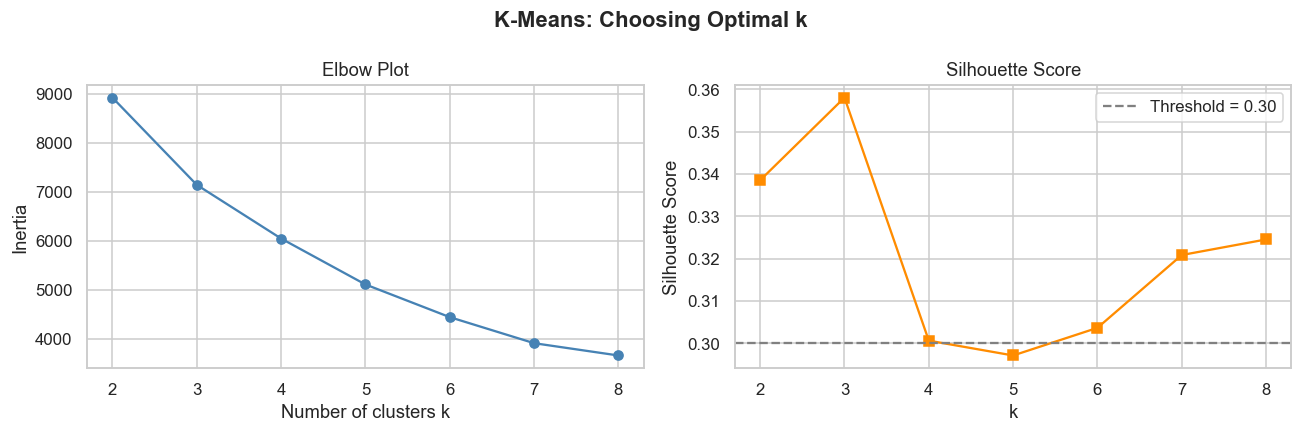

Best k by silhouette: 3 (score = 0.358)


In [ ]:
# ── 2b. Elbow & Silhouette ────────────────────────────────────────────────────
K_range = range(2, 9)
inertias, silhouettes = [], []
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
for k in K_range:
    km = KMeans(n_clusters=k, random_state=122, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil=silhouette_score(X_scaled, labels, sample_size=5000, random_state=122)
    silhouettes.append(sil)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_range), inertias, 'o-', color='steelblue')
ax1.set_xlabel('Number of clusters k'); ax1.set_ylabel('Inertia'); ax1.set_title('Elbow Plot')
ax2.plot(list(K_range), silhouettes, 's-', color='darkorange')
ax2.axhline(0.3, color='gray', linestyle='--', label='Threshold = 0.30')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score'); ax2.set_title('Silhouette Score'); ax2.legend()
plt.suptitle('K-Means: Choosing Optimal k', fontweight='bold')
plt.tight_layout(); plt.show()

best_k = list(K_range)[np.argmax(silhouettes)]
final_sil = max(silhouettes)
print(f'Best k by silhouette: {best_k} (score = {max(silhouettes):.3f})')

In [80]:
# ── 2c. Fit final K-Means ─────────────────────────────────────────────────────
N_CLUSTERS = 3
km_final = KMeans(n_clusters=N_CLUSTERS, random_state=122, n_init=20)
stint_clean = stint_clean.copy()
stint_clean['cluster'] = km_final.fit_predict(X_scaled)

print(f'k={N_CLUSTERS}, silhouette={silhouette_score(X_scaled, stint_clean["cluster"]):.3f}')
print(stint_clean['cluster'].value_counts().sort_index())

k=3, silhouette=0.358
cluster
0    1612
1    1582
2     130
Name: count, dtype: int64


In [81]:
# ── 2d. Cluster labelling ─────────────────────────────────────────────────────
cluster_means = stint_clean.groupby('cluster')[cluster_cols].mean().round(2)
print('Cluster centroids (original scale):'); print(cluster_means)

def label_cluster(row):
    if row['stint_length'] < cluster_means['stint_length'].median() and \
       row['compound_hardness'] <= cluster_means['compound_hardness'].median():
        return 'Aggressive (Short-Soft)'
    elif row['stint_length'] > cluster_means['stint_length'].median() and \
         row['compound_hardness'] >= cluster_means['compound_hardness'].median():
        return 'Conservative (Long-Hard)'
    else:
        return 'Standard (Medium)'

cluster_label_map = {i: label_cluster(cluster_means.loc[i]) for i in cluster_means.index}
for i, (k, v) in enumerate(cluster_label_map.items()):
    cluster_label_map[k] = v if list(cluster_label_map.values()).count(v) == 1 else f'{v} ({k})'

stint_clean['cluster_label'] = stint_clean['cluster'].map(cluster_label_map)
print('\nLabel map:', cluster_label_map)

Cluster centroids (original scale):
         stint_length  compound_hardness  first_pit_progress  deg_mean
cluster                                                               
0               26.13               2.77                0.37     -0.13
1               16.59               1.69                0.86      0.07
2               32.05               2.36                0.64     -7.30

Label map: {0: 'Standard (Medium)', 1: 'Aggressive (Short-Soft)', 2: 'Conservative (Long-Hard)'}


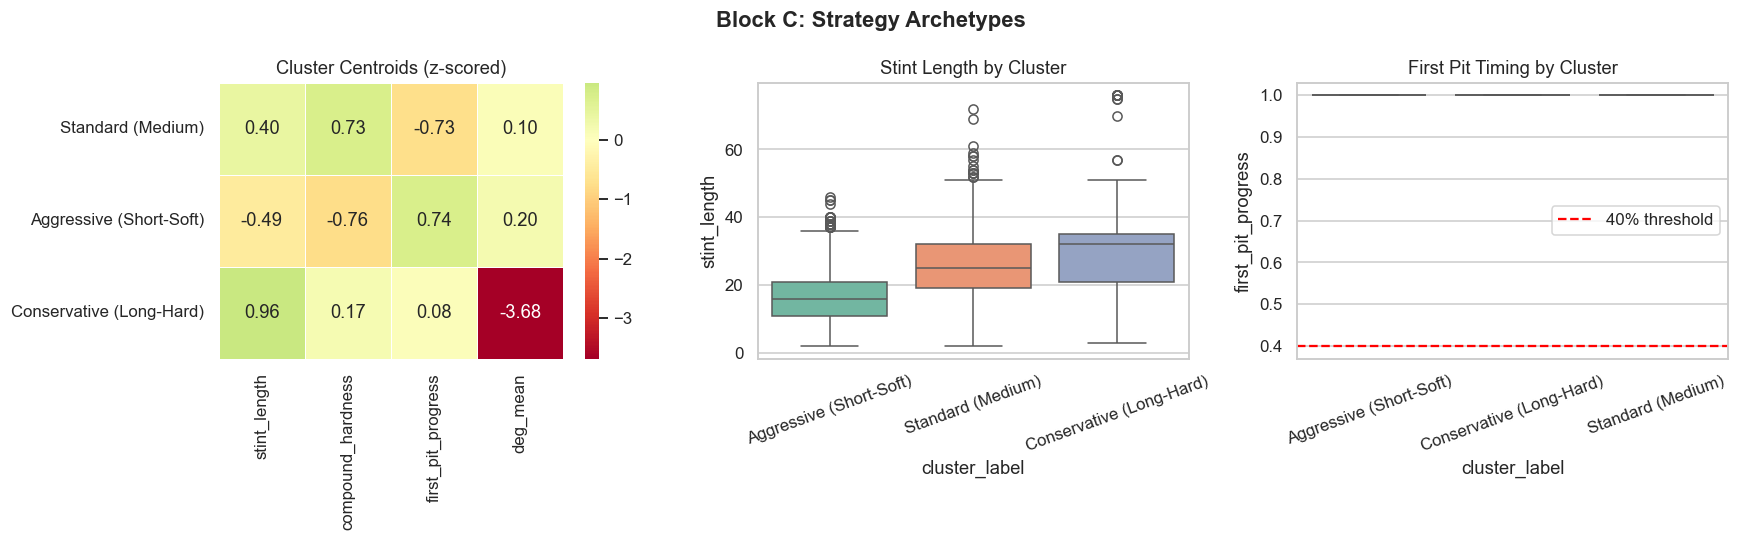

In [82]:
# ── 2e. Cluster visualisations ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

centroids_norm = pd.DataFrame(
    scaler.transform(cluster_means), columns=cluster_cols,
    index=[cluster_label_map[i] for i in cluster_means.index]
)
sns.heatmap(centroids_norm, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=axes[0], linewidths=0.5)
axes[0].set_title('Cluster Centroids (z-scored)')

sns.boxplot(data=stint_clean, x='cluster_label', y='stint_length', ax=axes[1], palette='Set2')
axes[1].set_title('Stint Length by Cluster'); axes[1].tick_params(axis='x', rotation=20)

sns.boxplot(data=stint_clean[stint_clean['Stint'] == 1],
            x='cluster_label', y='first_pit_progress', ax=axes[2], palette='Set2')
axes[2].axhline(0.40, color='red', linestyle='--', label='40% threshold')
axes[2].set_title('First Pit Timing by Cluster'); axes[2].tick_params(axis='x', rotation=20); axes[2].legend()

plt.suptitle('Block C: Strategy Archetypes', fontweight='bold')
plt.tight_layout(); plt.show()

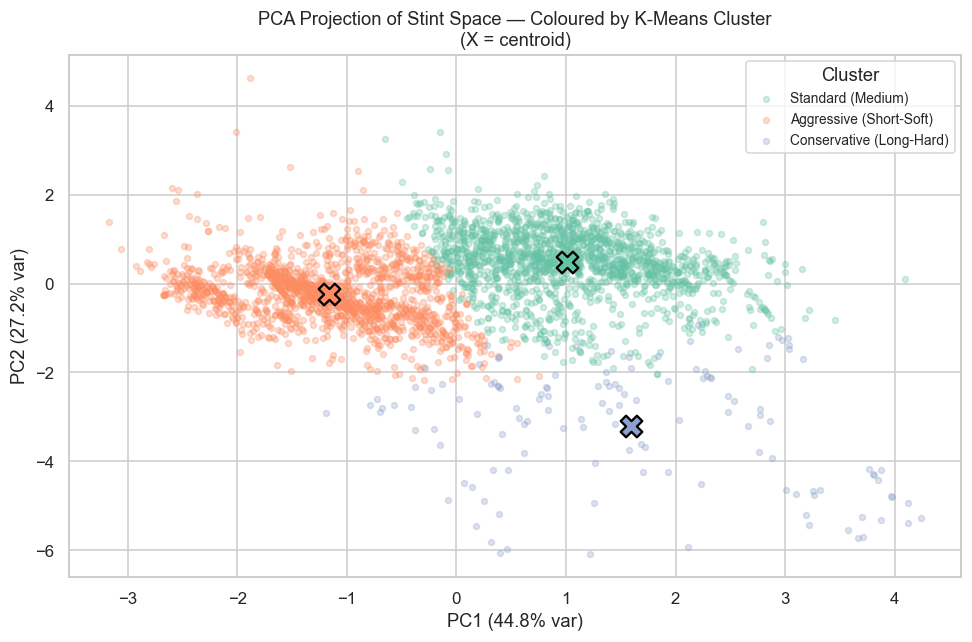

PC1+PC2 explain 72.0% of variance


In [83]:
# ── 2f. PCA projection of stint space coloured by cluster ─────────────────────
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=122)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('Set2', N_CLUSTERS)
for c_id in range(N_CLUSTERS):
    mask = stint_clean['cluster'] == c_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               alpha=0.3, s=15, color=palette[c_id], label=cluster_label_map[c_id])

# Plot centroids in PCA space
centroids_pca = pca.transform(km_final.cluster_centers_)
for c_id in range(N_CLUSTERS):
    ax.scatter(centroids_pca[c_id, 0], centroids_pca[c_id, 1],
               marker='X', s=200, color=palette[c_id], edgecolors='black', linewidths=1.5, zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('PCA Projection of Stint Space — Coloured by K-Means Cluster\n(X = centroid)')
ax.legend(title='Cluster', fontsize=9)
plt.tight_layout(); plt.show()
print(f'PC1+PC2 explain {sum(pca.explained_variance_ratio_[:2])*100:.1f}% of variance')

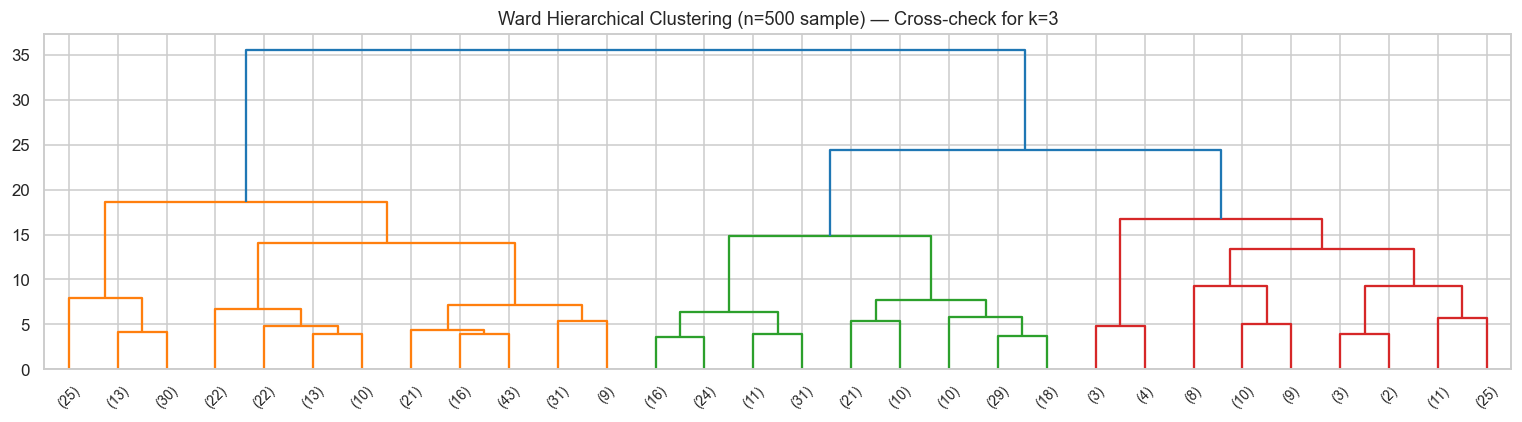

Silhouette — K-Means: 0.371  |  Hierarchical: 0.329


In [84]:
# ── 2g. Hierarchical clustering cross-check ───────────────────────────────────
sample_idx = np.random.choice(len(X_scaled), size=min(500, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]
Z = linkage(X_sample, method='ward')
hier_labels = fcluster(Z, t=N_CLUSTERS, criterion='maxclust')

fig, ax = plt.subplots(figsize=(14, 4))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, leaf_rotation=45, leaf_font_size=9,
           color_threshold=Z[-(N_CLUSTERS-1), 2])
ax.set_title(f'Ward Hierarchical Clustering (n=500 sample) — Cross-check for k={N_CLUSTERS}')
plt.tight_layout(); plt.show()

hier_sil = silhouette_score(X_sample, hier_labels)
km_sil_s = silhouette_score(X_sample, km_final.predict(X_sample))
print(f'Silhouette — K-Means: {km_sil_s:.3f}  |  Hierarchical: {hier_sil:.3f}')

=== ANOVA: Cluster Differences on Raw Features ===
                            F    p  eta_sq  significant
stint_length         491.8501  0.0  0.2285         True
compound_hardness   1967.3985  0.0  0.5423         True
first_pit_progress  1843.5239  0.0  0.5261         True
deg_mean            2067.7771  0.0  0.5546         True


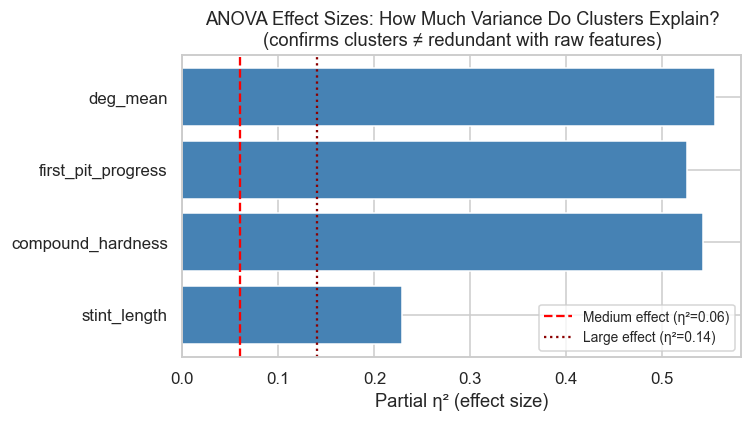

In [85]:
# ── 2h. ANOVA: cluster synthesis validation (Kira Requirement 2) ──────────────
anova_results = {}
groups_by_cluster = {col: [g[col].dropna().values for _, g in stint_clean.groupby('cluster')]
                     for col in cluster_cols}

for col, groups in groups_by_cluster.items():
    F, p = stats.f_oneway(*groups)
    all_vals = np.concatenate(groups)
    grand_mean = all_vals.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = np.sum((all_vals - grand_mean)**2)
    eta2 = ss_between / ss_total
    anova_results[col] = {'F': F, 'p': p, 'eta_sq': eta2}

anova_df = pd.DataFrame(anova_results).T.round(4)
anova_df['significant'] = anova_df['p'] < 0.05
print('=== ANOVA: Cluster Differences on Raw Features ===')
print(anova_df)

# Visualise eta-squared
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(anova_df.index, anova_df['eta_sq'], color='steelblue', edgecolor='white')
ax.axvline(0.06, color='red', linestyle='--', label='Medium effect (η²=0.06)')
ax.axvline(0.14, color='darkred', linestyle=':', label='Large effect (η²=0.14)')
ax.set_xlabel('Partial η² (effect size)')
ax.set_title('ANOVA Effect Sizes: How Much Variance Do Clusters Explain?\n(confirms clusters ≠ redundant with raw features)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

In [86]:
# ── 2i. Assign dominant cluster per driver-race ───────────────────────────────
race_key = ['Driver', 'Race', 'Year']   # driver-race level (no Stint)

dominant_cluster = (
    stint_clean.groupby(race_key, as_index=False)
    .agg(strategy_cluster=('cluster', lambda x: x.mode().iloc[0]),
         strategy_cluster_label=('cluster_label', lambda x: x.mode().iloc[0]))
)

# Merge dominant cluster into the driver-race frame used by the supervised block
race_all_c = race_all.merge(dominant_cluster, on=race_key, how='left')
race_all_c['strategy_cluster'] = race_all_c['strategy_cluster'].fillna(-1).astype(int)
print(race_all_c['strategy_cluster_label'].value_counts())

strategy_cluster_label
Aggressive (Short-Soft)     846
Standard (Medium)           410
Conservative (Long-Hard)     63
Name: count, dtype: int64


**Conclusion — the cluster adds no *practically meaningful* predictive value.** The nested ANOVA is statistically significant (F ≈ 6.3, *p* ≈ 0.01), but the **effect size is negligible**: adjusted R² rises by only ~0.003 (0.333 → 0.336) and test-set RMSE improves by ~0.001 position. With n ≈ 1,190 even a trivial difference is detectable — *statistical* significance here is not *practical* importance. The clusters are cleanly separated by raw first-pit timing (right panel) yet barely separate the outcome (left). **We keep them for their real value — interpretable archetypes and a corroborating anchor for the causal treatment definition — but transparently report they add no *meaningful* predictive signal.**

## Section 5 — Synthesis & Communication  *(4 pts)*

### How the blocks connect (one outcome, three lenses)
1. **Unsupervised (tested last) → Supervised/Causal:** we explicitly evaluated whether the archetypes add predictive value — they are statistically detectable but **practically negligible** (adj R² +0.003, test RMSE −0.001), so their value is descriptive and as a corroborating anchor for the causal treatment definition, not as a predictive feature.
2. **Supervised → Causal:** the predictive model showed strategy is a *weak but real* lever — in time-series CV the full-feature models modestly beat the grid-only baseline (≈3.05 vs 3.35 RMSE; on the single 2025 holdout they roughly tie it) — foreshadowing the *small* causal effect; its mechanism check confirmed the DAG's *degradation → pit* arrow (AUC ≈ 0.95).
3. **Causal robustness:** the sensitivity analysis showed the negative ATE holds across 30–50% thresholds, and the window analysis showed *why* — harm concentrates in sub-30% stops while 30–50% is best. Our **preferred estimate uses two-way fixed effects** (race + constructor), identifying the effect *within-race* (ATE −0.97, p ≈ 0.04) and corroborated by Double ML — adjusting for confounders this thoroughly is what makes every statement trustworthy.

In [88]:
summary=pd.DataFrame([
    ['Unsupervised', f'Archetypes (silhouette, K=3)', f'{final_sil:.3f}'],
    ['Unsupervised','Cluster-validity: gap statistic', f'optimal k={gap_k} (no discrete clusters)'],
    ['Supervised','Grid-only baseline RMSE (2025 test)', f'{grid_rmse:.3f}'],
    ['Supervised','CV RMSE grid-only vs best model', f'{cv_grid:.2f} vs {cv_best:.2f}'],
    ['Supervised','Random Forest RMSE (2025)', f'{rmse(yte,rf_p):.3f}'],
    ['Supervised','Pit-decision mechanism AUC', f'{mech_auc:.3f}'],
    ['Supervised','Mixed-effects variance (circuit / residual)', f'{vc_cir/vc_tot:.0%} / {vc_res/vc_tot:.0%}'],
    ['Supervised','Decision target - podium OVR-AUC (2025)', f'{auc_pod:.3f}'],
    ['Causal','ATE early-pit (linear reg.)', f'{estimate.value:+.3f}'],
    ['Causal','ATE early-pit (PS weighting)', f'{estimate_psw.value:+.3f}'],
    ['Causal','ATE two-way FE (race+constructor) [preferred]', f'{ate_robust:+.2f} (p={p_robust:.3f})'],
    ['Causal','ATE Double ML (cross-fitted)', f'{ate_dml:+.2f} (p={p_dml:.3f})'],
    ['Causal','ATE easy-overtaking circuits (exploratory)', f'{het_easy_ate:+.2f} (p={het_easy_p:.3f})'],
    ['Robustness','ATE sign across 30-50% thresholds', f'negative ({sens.ATE.min():+.2f} to {sens.ATE.max():+.2f})'],
    ['Robustness','Cluster predictive value', f'negligible (dRMSE {rmse_withcluster-rmse_nocluster:+.3f})'],
    ['Window','Optimal first-pit window', best],
    ['Window','Adjusted gain at optimum', f'{adj[best]:+.2f}'],
],columns=['Block','Metric','Value']); summary

NameError: name 'final_sil' is not defined

### Conclusion — answering the research question
**Pit-stop strategy shapes race performance only modestly:** net position gain is dominated by grid slot and car quality, with strategy a *small but real* lever — in time-series CV the full-feature models modestly beat a grid-only baseline (≈3.05 vs 3.35 RMSE), though the signal is weak (R² ~0.1–0.2). **Early pitting does *not* causally help** — the adjusted ATE of pitting before 40% is ≈ **−0.3 positions**, robust across thresholds and specifications — strengthening as identification tightens to **−0.97 under the preferred two-way fixed-effects design (race + constructor FE), p ≈ 0.04** with race-clustered SEs, and corroborated by a cross-fitted Double ML estimate (≈ −0.74, p ≈ 0.03, negative in all 10 cross-fitting seeds); the effect is identified by comparing early- vs late-pitters *within the same race* — but the window analysis refines this into an **inverted-U whose optimum is the mid-race 30–50% undercut window**, with pitting before ~30% clearly destroying value. Economically sensible: fresh tyres only repay the ~20 s pit-lane loss once the old set has degraded enough.

### Limitations & potential confounders
- **Interference / SUTVA (structural):** positions are zero-sum within a race — one driver's early pit mechanically changes rivals' outcomes and triggers their strategic responses, so the no-interference assumption behind the ATE fails by construction. Our estimate is the average *individual* advantage of pitting early *given rivals' observed behaviour*, not the effect of all drivers changing strategy simultaneously (a general-equilibrium counterfactual this data cannot identify). We mitigate the within-race dependence by clustering standard errors at the race level.
- **No real SC/VSC flags** (corrupted) → backdoor adjustment, not IV.
- **2022 weather missing** → causal block on 2023–24.
- **Low predictive R² / noisy outcome** (DNFs, crashes) → reported honestly; baseline comparison is the test.
- **Coarse car tier** (static per year) → constructor fixed effects as future work.
- **Residual endogeneity** (unobserved race pace) → two estimators + refutation tests.
- **Small per-window samples** → broad optimal region reported, not a single lap.

## References
- OpenF1 API — open Formula 1 timing & telemetry data. https://openf1.org (accessed 2026).
- Sharma, A., & Kiciman, E. (2020). *DoWhy: An end-to-end library for causal inference.* arXiv:2011.04216.
- Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR, 12, 2825–2830.
- Seabold, S., & Perktold, J. (2010). *statsmodels: Econometric and statistical modeling with Python.* SciPy.
- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.). Cambridge University Press.
- McKinney, W. (2010). *Data structures for statistical computing in Python.* (pandas). SciPy.